<a href="https://colab.research.google.com/github/kjfcvx12/Colab/blob/main/04_20_p1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Conv2d - 3번 (3, 16) - (16,32) - (32,64)

에폭은 10번

훈련, 검증, 평가로 나눠서 작업하기

모델 평가도 한다.

예측정도를 confusion_matrix로 나타내기

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets
from torchvision.transforms import transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
from torch.utils.data.sampler import SubsetRandomSampler

In [2]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
composed=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1,),(0.3,))
])

In [4]:
train_data = datasets.CIFAR10(root='./data',
                              train=True,
                              download=True,
                              transform=composed)

test_data = datasets.CIFAR10(root='./data',
                             train=False,
                             download=True,
                             transform=composed)

100%|██████████| 170M/170M [00:13<00:00, 12.8MB/s]


In [5]:
in_data=list(range(50000)) # [0,1, ..... 59999]
np.random.shuffle(in_data) # 번호표를 무작위로 섞어놓음
split_data=int(np.floor(0.2*50000)) # 12000개는 train-validation용으로 설정 48000개는 train용

# train_index : 12001번째부터 마지막까지(48000개) - 학습용
# valid_index : 처음부터 12000번째까지(12000개) - 검증용
train_index, valid_index=in_data[split_data:], in_data[:split_data]

In [6]:
# DataLoader에 전달될때, 12000, 48000 인덱스에 해당하는 데이터를 무작위로 추출하려고
train_sample=SubsetRandomSampler(train_index)
valid_sample=SubsetRandomSampler(valid_index)

In [7]:
# SubsetRandomSampler - DataLoader
# DataLoader 가 다음 값 요청하면 샘플러가 인덱스 하나를 무작위로 던져주는 구조(호환됨)
train_loader=DataLoader(train_data, batch_size=128, sampler=train_sample)
vaild_loader=DataLoader(train_data, batch_size=128, sampler=valid_sample)
# 60000개를 무작위로 섞은 후 80% 학습 20% 검즘용으로 나눔

# 평가시에 데이터 순서가 섞이면 모델 성능 비교 불안정해짐 -> 섞지 않음
test_loader=DataLoader(test_data, batch_size=128, shuffle=False) # 10000개

In [13]:
class LeNet(nn.Module):
  def __init__(self):
    super().__init__()
    # 입력 -> 특징추출
    self.conv1=nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, padding=2)
    self.conv2=nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5)
    self.conv3=nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5)
    # 특징 -> 분류
    self.maxpool=nn.MaxPool2d(2) # 2*2
    self.relu=nn.ReLU()
    # 2번씩 conv, maxpool 시킨 결과
    self.fc1 = nn.Linear(64, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)

  def forward(self, x):
    x=self.relu(self.conv1(x))
    x=self.maxpool(x)
    x=self.relu(self.conv2(x))
    x=self.maxpool(x)
    x=self.relu(self.conv3(x))
    x=self.maxpool(x)
    # 2D -> 1D
    # fully connected에 전달할 준비!!
    x=torch.flatten(x,1)
    # FC Lavaer
    x=self.relu(self.fc1(x))
    x=self.relu(self.fc2(x))
    out=self.fc3(x)
    return out

In [14]:
model=LeNet()
model

LeNet(
  (conv1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
  (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=64, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [15]:
# 다중 분류에서 가장 많이 쓰이는 손실함수
crossloss=nn.CrossEntropyLoss()
# 모델을 cpu로 올린 후에 입력데이터도 cpu로 이동시킴
model.to(device)

LeNet(
  (conv1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
  (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=64, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [16]:
optimizer=torch.optim.SGD(model.parameters(), lr=0.01)

In [17]:
loss1, acc1=[], []
for epoch in range(10):
  model.train()
  t_loss=0 # 손실 초기화
  t_acc=0 # 정확도 초기화

  for i,j in train_loader:
    i,j=i.to(device), j.to(device)



    z=model(i)
    loss=crossloss(z,j) # CrossEntropyLoss 통해 모델 예측값과 실제 정답사이의 오차
    t_loss+=loss.item()
    # 가장 높은 점수를 뽑아내지 않고, 그게 몇번 클래스인지 알아내기 위해서
    _,y_pred=torch.max(z,1) # 가장 높은 점수를 가진 클래스 인덱스 => (_ : 최대값, y_pred :예측 클래스 번호)
    t_acc+=(y_pred==j).sum().item()

    optimizer.zero_grad() # 기울기 초기화
    loss.backward() # 기울기 계산
    optimizer.step() # 가중치 업데이트

  t_loss=t_loss/len(train_sample)
  t_acc=t_acc/len(train_sample)

  loss1.append(t_loss)
  acc1.append(t_acc)

  print(loss1)
  print(acc1)

[0.018018474137783052]
[0.1016]
[0.018018474137783052, 0.017984481102228164]
[0.1016, 0.14715]
[0.018018474137783052, 0.017984481102228164, 0.01786188884973526]
[0.1016, 0.14715, 0.130175]
[0.018018474137783052, 0.017984481102228164, 0.01786188884973526, 0.016934131741523743]
[0.1016, 0.14715, 0.130175, 0.18915]
[0.018018474137783052, 0.017984481102228164, 0.01786188884973526, 0.016934131741523743, 0.015868714335560797]
[0.1016, 0.14715, 0.130175, 0.18915, 0.2503]
[0.018018474137783052, 0.017984481102228164, 0.01786188884973526, 0.016934131741523743, 0.015868714335560797, 0.015320904701948166]
[0.1016, 0.14715, 0.130175, 0.18915, 0.2503, 0.276925]
[0.018018474137783052, 0.017984481102228164, 0.01786188884973526, 0.016934131741523743, 0.015868714335560797, 0.015320904701948166, 0.014772735565900802]
[0.1016, 0.14715, 0.130175, 0.18915, 0.2503, 0.276925, 0.314775]
[0.018018474137783052, 0.017984481102228164, 0.01786188884973526, 0.016934131741523743, 0.015868714335560797, 0.0153209047019

In [18]:
pred=[]
label=[]

# 모델을 평가모드설정(생략해도됨) -> dropout 이 off 됨
model.eval()
# inference_mode : gradient 비활성 -> 메모리 절약
with torch.inference_mode():
  for i,j in test_loader:
    # 데이터를 현재 디바이스로 이동
    i,j=i.to(device), j.to(device)
    z=model(i)
    val, y_pred=torch.max(z,1)
    # 리스트에 배치단위(128) 결과들을 각각 이어붙인다.
    # numpy는 gpu에 있는 데이터 직접 다룰 수 없음 -> cpu로 바꿔서 가져와야
    pred.extend(y_pred.cpu().numpy())
    label.extend(j.cpu().numpy())

In [19]:
answer=np.nonzero(np.array(pred)==np.array(label))[0]
incorrect=np.nonzero(np.array(pred)!=np.array(label))[0]

#전체 샘플 중 맞춘 비율
print(len(answer)/len(pred)*100)

43.5


[[455 111  51  36  13  17  25  72 143  77]
 [ 16 687   3  11   5  11  28  37  41 161]
 [ 77  44 173  87 129 164 140 139  25  22]
 [ 16  47  57 207  17 338 130 121  13  54]
 [ 38  29 101  49 280 106 177 172  27  21]
 [ 11  24  65 107  21 508  96 126  20  22]
 [  1  21  39  96 106 105 534  43   5  50]
 [ 16  30  30  69  48 122  47 574   9  55]
 [156 151   7  23   3  29  17  30 435 149]
 [ 23 270   2  37   2  15  42  53  59 497]]
45.5
68.7
17.299999999999997
20.7
28.000000000000004
50.8
53.400000000000006
57.4
43.5
49.7


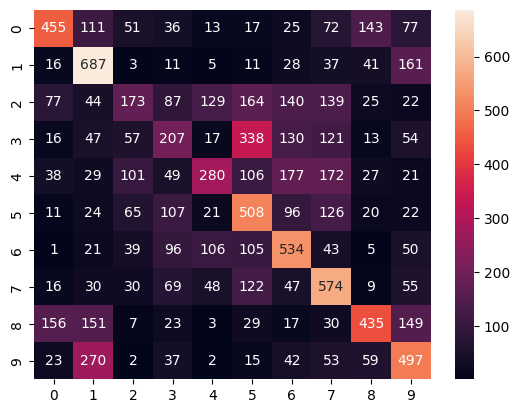

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

con_mtx=confusion_matrix(label, pred)
print(con_mtx)
# 각 셀에 숫자표시(annot), 정수형으로 표시(fmt='d')
sns=sns.heatmap(con_mtx, annot=True, fmt='d')
for i in range(10):
  # con_mtx[i][i] : 실제 i인 샘플 중 올바르게 예측된 수
  # con_mtx[i].sum() : 실제 i클래스의 전체 샘플 수
  # => 각 클래스별로 정확도 계산함
  print(con_mtx[i][i]/con_mtx[i].sum()*100)